# Notebook 01 — Fundamentos de raster con `rasterio`

En este notebook abrimos el GeoTIFF Sentinel-2 descargado en el notebook 00, inspeccionamos sus metadatos y lo visualizamos con `rasterio.plot.show` y `matplotlib`.

**Salida**: `media/01_raster_basics.png`

In [1]:
from pathlib import Path
import os
import numpy as np
import rasterio
from rasterio.plot import show, show_hist
import matplotlib.pyplot as plt

# Anclar el directorio de trabajo al raíz del taller.
# Se busca el archivo Sentinel-2 hacia arriba desde el cwd hasta encontrarlo.
def find_taller_root(start: Path, marker: str = "python/data/bogota_sabana_sentinel2.tif") -> Path:
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"No se encontró {marker} desde {start}")

ROOT = find_taller_root(Path.cwd())
os.chdir(ROOT)
DATA = ROOT / "python" / "data"
MEDIA = ROOT / "media"
MEDIA.mkdir(exist_ok=True)

tif = DATA / "bogota_sabana_sentinel2.tif"
print("ROOT:", ROOT)
print("Archivo:", tif)
print("Tamaño:", tif.stat().st_size / 1024, "KB")

ROOT: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales
Archivo: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/python/data/bogota_sabana_sentinel2.tif
Tamaño: 551.1162109375 KB


In [2]:
src = rasterio.open(tif)
print("=== Metadatos del raster ===")
print(f"  Driver:        {src.driver}")
print(f"  Width x Height:{src.width} x {src.height}")
print(f"  Bandas:        {src.count}")
print(f"  dtype:         {src.dtypes[0]}")
print(f"  CRS:           {src.crs}")
print(f"  Transform:     {src.transform}")
print(f"  Bounds:        {src.bounds}")
print(f"  Resolution:    {src.res}")
print(f"  Tags:          {src.tags()}")
print(f"  Band tags:     {[src.tags(i+1) for i in range(src.count)]}")
src.close()

=== Metadatos del raster ===
  Driver:        GTiff
  Width x Height:256 x 256
  Bandas:        4
  dtype:         uint16
  CRS:           EPSG:4326
  Transform:     | 0.00, 0.00,-74.25|
| 0.00,-0.00, 4.82|
| 0.00, 0.00, 1.00|
  Bounds:        BoundingBox(left=-74.25038794439317, bottom=4.4994429744475015, right=-73.89943073843078, top=4.820514192456842)
  Resolution:    (0.0013709265857905692, 0.0012541844453489849)
  Tags:          {'AREA_OR_POINT': 'Area'}
  Band tags:     [{}, {}, {}, {}]


In [3]:
with rasterio.open(tif) as src:
    b02 = src.read(1)  # Blue
    b03 = src.read(2)  # Green
    b04 = src.read(3)  # Red
    b08 = src.read(4)  # NIR
    bounds = src.bounds
    transform = src.transform

print("B02 (Blue)  shape:", b02.shape, "min/max:", b02.min(), b02.max())
print("B03 (Green) shape:", b03.shape, "min/max:", b03.min(), b03.max())
print("B04 (Red)   shape:", b04.shape, "min/max:", b04.min(), b04.max())
print("B08 (NIR)   shape:", b08.shape, "min/max:", b08.min(), b08.max())

B02 (Blue)  shape: (256, 256) min/max: 1064 6835
B03 (Green) shape: (256, 256) min/max: 1148 7124
B04 (Red)   shape: (256, 256) min/max: 1091 7011
B08 (NIR)   shape: (256, 256) min/max: 1048 6783


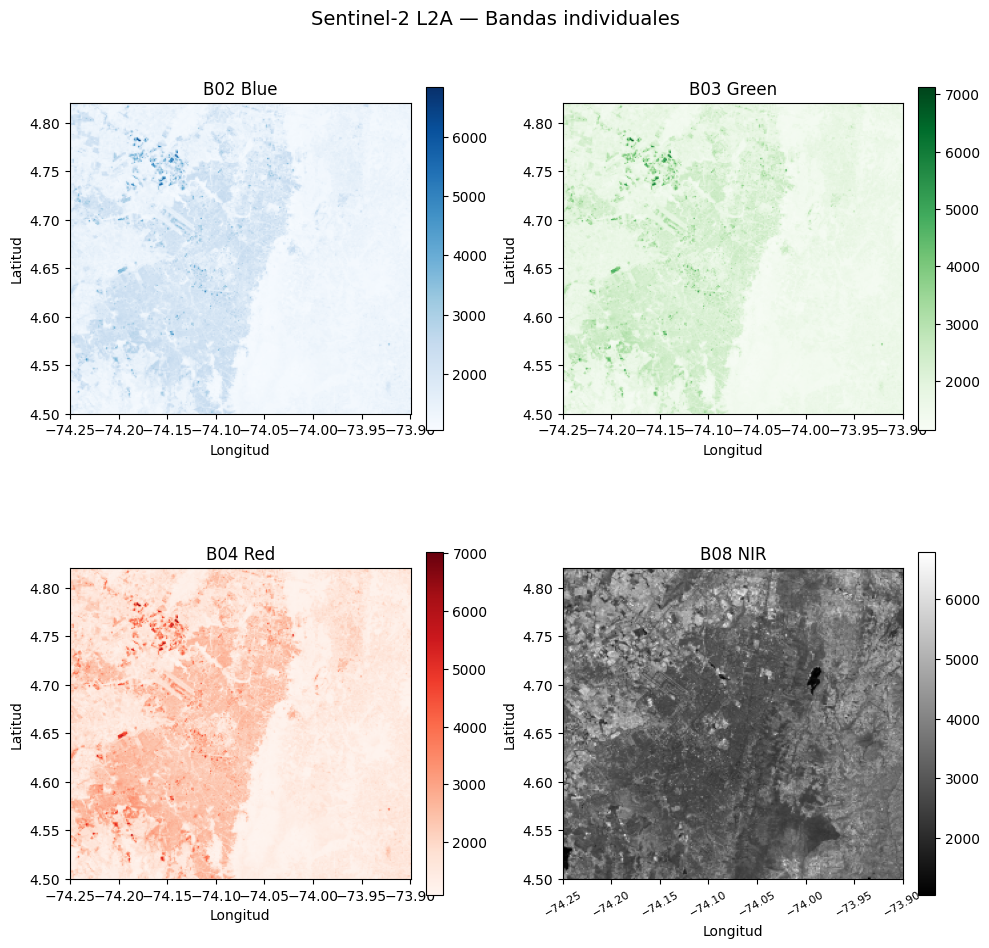

Guardado: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/media/01_raster_basics.png


In [4]:
band_names = ["B02 Blue", "B03 Green", "B04 Red", "B08 NIR"]
bands = [b02, b03, b04, b08]
cmaps = ["Blues", "Greens", "Reds", "gray"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, name, band, cmap in zip(axes.ravel(), band_names, bands, cmaps):
    im = ax.imshow(band, cmap=cmap, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax.set_title(name)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Sentinel-2 L2A — Bandas individuales", fontsize=14)
plt.gca().tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
out = MEDIA / "01_raster_basics.png"
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {out}")

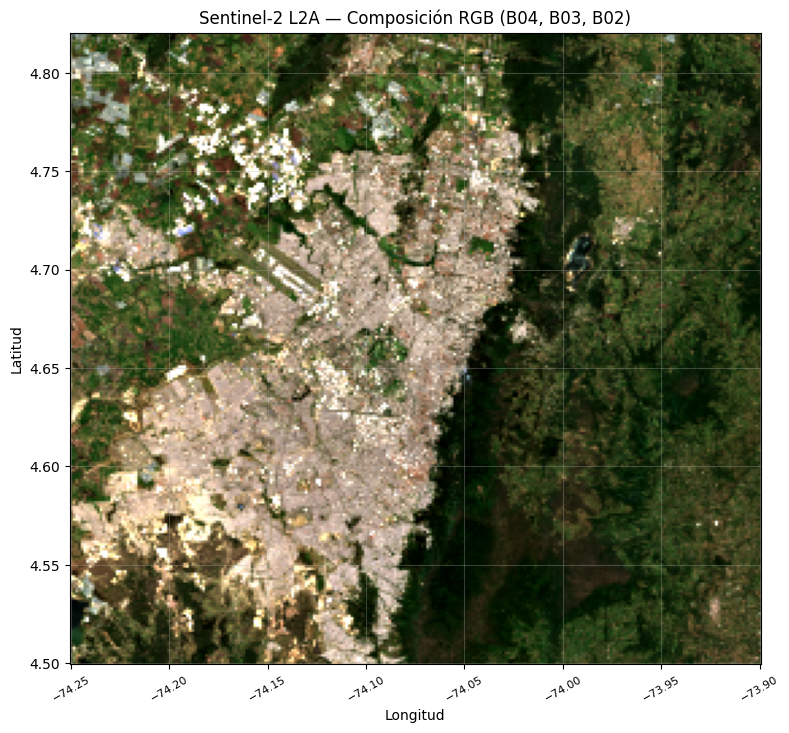

In [5]:
rgb = np.stack([b04, b03, b02], axis=-1).astype(np.float32)
vmin, vmax = np.nanpercentile(rgb, [2, 98])
rgb_stretched = np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_stretched, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
ax.set_title("Sentinel-2 L2A — Composición RGB (B04, B03, B02)")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.grid(True, alpha=0.3)
plt.gca().tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig(MEDIA / "01_raster_basics_rgb.png", dpi=120, bbox_inches="tight")
plt.show()

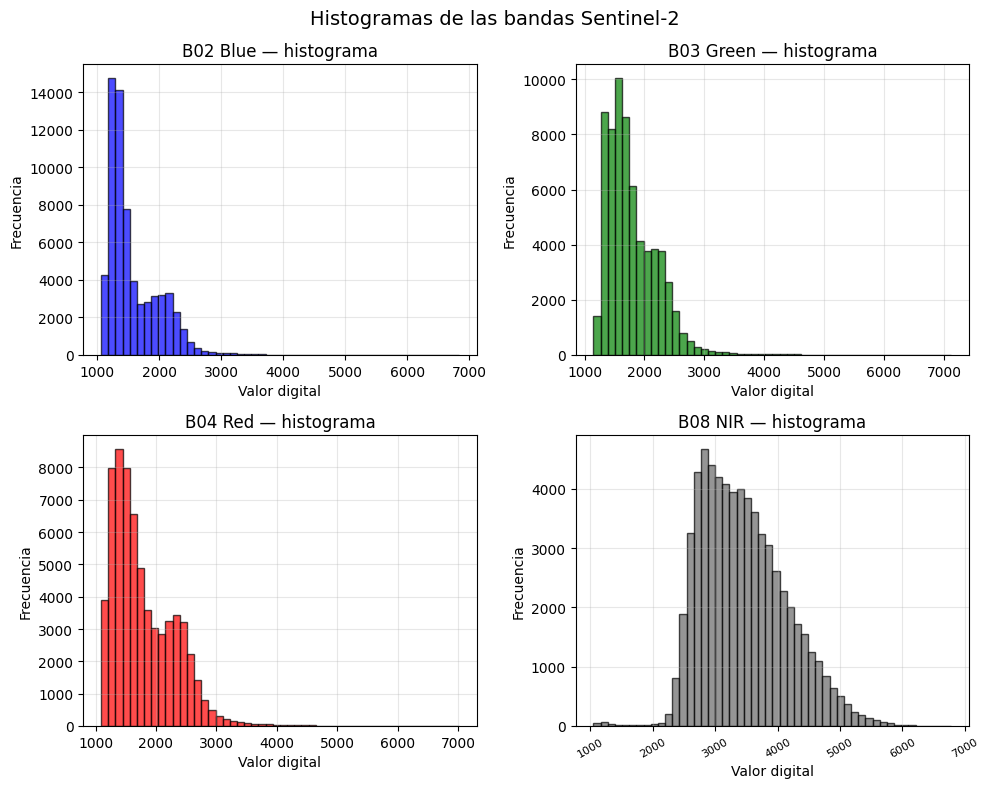

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, name, band, color in zip(
    axes.ravel(),
    band_names,
    bands,
    ["blue", "green", "red", "dimgray"],
):
    ax.hist(band.ravel(), bins=50, color=color, alpha=0.7, edgecolor="black")
    ax.set_title(f"{name} — histograma")
    ax.set_xlabel("Valor digital")
    ax.set_ylabel("Frecuencia")
    ax.grid(True, alpha=0.3)
fig.suptitle("Histogramas de las bandas Sentinel-2", fontsize=14)
plt.gca().tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig(MEDIA / "01_raster_basics_hist.png", dpi=120, bbox_inches="tight")
plt.show()

## Conclusiones

- El raster tiene 4 bandas (B02, B03, B04, B08), 256×256 píxeles, dtype `uint16` (valores de reflectancia ×10000 según convención Sentinel-2 L2A).
- El CRS es `EPSG:4326` (geográfico, grados decimales).
- Los bounds corresponden a la Sabana de Bogotá.
- En el notebook 03 calcularemos el **NDVI** combinando B04 (Red) y B08 (NIR).